# CNN/RNN Hybrid Model Runner

---
## 1 · Settings


In [5]:
import torch

# ── RNN architecture ──────────────────────────────────────────────────────────
RNN_NUM_LAYERS    = 2     # number of GRU layers
RNN_HIDDEN_SIZE   = 384   # hidden units per layer
RNN_BIDIRECTIONAL = True  # True = Bi-GRU

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 32           # reduce to 16 if OOM

# ── Hardware (auto-detected) ───────────────────────────────────────────────────
ACCELERATOR = "gpu" if torch.cuda.is_available() else "cpu"
DEVICES     = torch.cuda.device_count() if torch.cuda.is_available() else 1

# ── Fixed ─────────────────────────────────────────────────────────────────────
MODEL = "cnn_rnn_ctc"
USER  = "single_user"

print(f"Accelerator : {ACCELERATOR}")
print(f"Devices     : {DEVICES}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
print(f"Model       : {MODEL}")

Accelerator : gpu
Devices     : 1
  GPU 0: NVIDIA GeForce RTX 3070
Model       : cnn_rnn_ctc


---
## 2 · Full Training

Checkpoints are saved under `logs/<date>/<time>/checkpoints/`. Update `CHECKPOINT` in Settings after training finishes.

In [8]:
!python -m emg2qwerty.train \
  model={MODEL} user={USER} \
  trainer.accelerator={ACCELERATOR} trainer.devices={DEVICES} \
  batch_size={BATCH_SIZE} \
  module.rnn_num_layers={RNN_NUM_LAYERS} \
  module.rnn_hidden_size={RNN_HIDDEN_SIZE} \
  module.rnn_bidirectional={RNN_BIDIRECTIONAL}

[2026-03-04 17:14:21,412][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

Global seed set to 1501
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: c:\Users\Michael\Documents\GitHub\sEMG2QWERTY\logs\2026-03-04\17-14-21\lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Michael\Documents\GitHub\sEMG2QWERTY\.venv\Lib\site-packages\pl_bolts\__init__.py:11: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
c:\Users\Michael\Documents\GitHub\sEMG2QWERTY\.venv\Lib\site-packages\pl_bolts\__init__.py:11: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
c:\Users\Michael\Documents\GitHub\sEMG2QWERTY\.venv\Lib\site-packages\pl_bolts\models\self_supervised\amdim\amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility wi

---
## 3 · Evaluation

The training run already tests with **greedy decoding** on the best checkpoint automatically.
Use these cells only to run **beam search**, or to re-evaluate an old checkpoint.

**Note:** Either paste your checkpoint path into `CHECKPOINT` in Settings,  
or run the auto-finder cell below to pick up the latest best checkpoint from `logs/`.

In [15]:
import glob, os

# Auto-find the best checkpoint from the most recent training run.
ckpt_candidates = sorted(
    glob.glob("logs/*/*/checkpoints/*.ckpt"),
    key=os.path.getmtime
)
best_ckpts = [p for p in ckpt_candidates if "last" not in os.path.basename(p)]
CHECKPOINT = best_ckpts[-1] if best_ckpts else ckpt_candidates[-1] if ckpt_candidates else CHECKPOINT

# Normalize to forward slashes — Hydra misparses backslashes and '=' in filenames
CHECKPOINT = CHECKPOINT.replace("\\", "/")

print(f"Using checkpoint: {CHECKPOINT}")
assert os.path.isfile(CHECKPOINT), f"Checkpoint not found: {CHECKPOINT}"

Using checkpoint: logs/2026-03-04/17-14-21/checkpoints/epoch=127-step=15360.ckpt


In [16]:
# Greedy Decoding — only needed to re-evaluate an old checkpoint
# (training already runs this automatically on the best checkpoint)
!python -m emg2qwerty.train train=False \
  model={MODEL} user={USER} \
  trainer.accelerator={ACCELERATOR} trainer.devices={DEVICES} \
  "checkpoint='{CHECKPOINT}'"

[2026-03-04 19:39:52,513][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

Global seed set to 1501
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: c:\Users\Michael\Documents\GitHub\sEMG2QWERTY\logs\2026-03-04\19-39-52\lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Michael\Documents\GitHub\sEMG2QWERTY\.venv\Lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


In [17]:
# Beam Search + Language Model — best accuracy
!python -m emg2qwerty.train train=False \
  model={MODEL} user={USER} \
  trainer.accelerator={ACCELERATOR} trainer.devices={DEVICES} \
  decoder=ctc_beam \
  "checkpoint='{CHECKPOINT}'"

[2026-03-04 19:40:06,290][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

Global seed set to 1501
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: c:\Users\Michael\Documents\GitHub\sEMG2QWERTY\logs\2026-03-04\19-40-06\lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Michael\Documents\GitHub\sEMG2QWERTY\.venv\Lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


---
## 4 · Training Curves

Reads TensorBoard event files from the most recent training run and plots loss and CER over epochs.

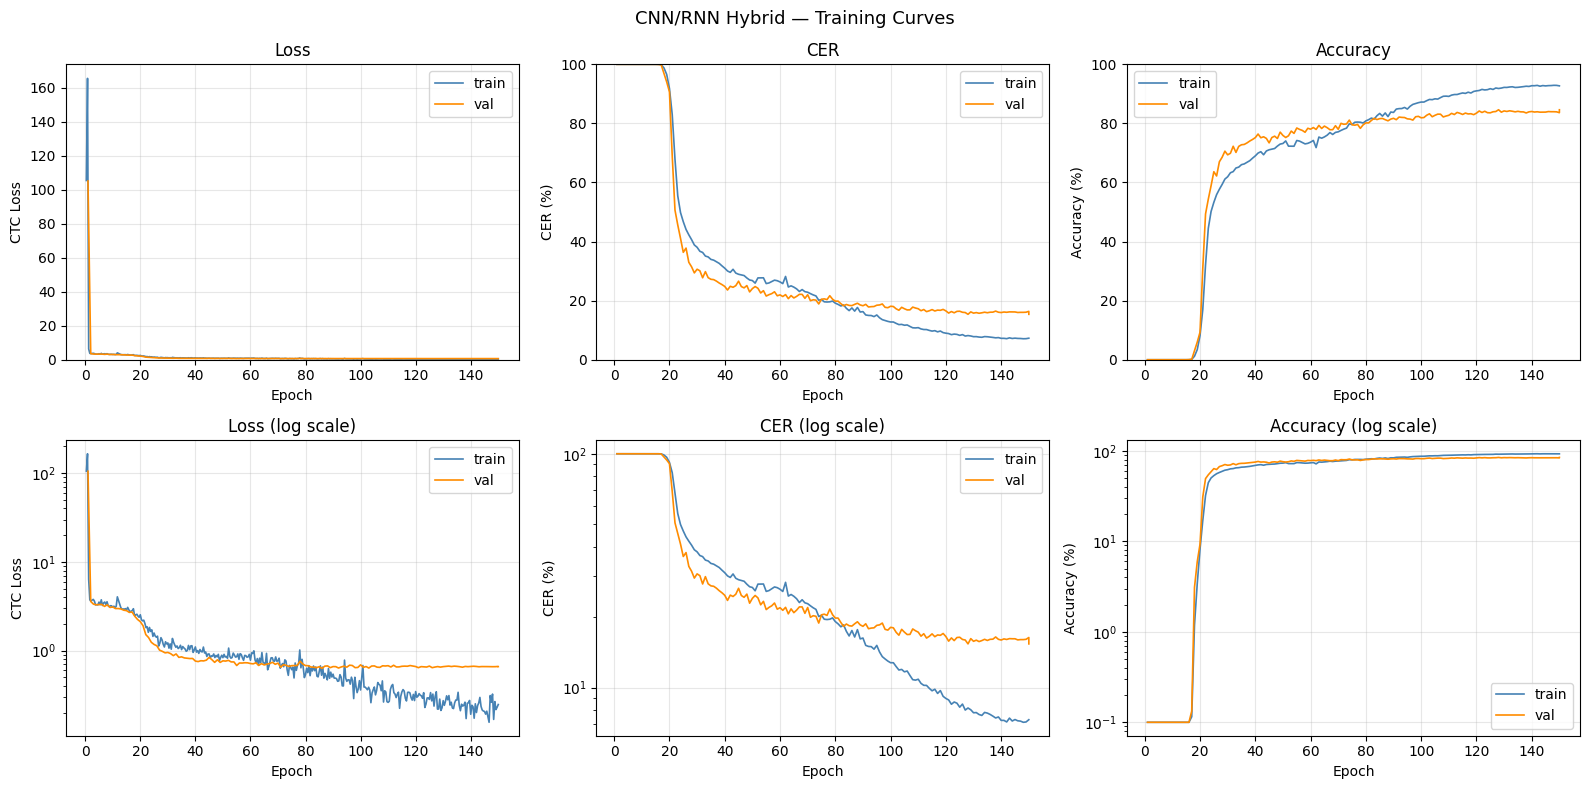

Saved to training_curves.png


In [28]:
import glob, os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ── Find training run log dir ─────────────────────────────────────────────────
def count_events(path):
    ea = EventAccumulator(path)
    ea.Reload()
    return sum(len(ea.Scalars(t)) for t in ea.Tags()["scalars"])

log_dirs = glob.glob("logs/*/*/lightning_logs/version_*")
assert log_dirs, "No TensorBoard logs found. Run training first."
log_dir = max(log_dirs, key=count_events)

ea = EventAccumulator(log_dir)
ea.Reload()

val_cer_events = ea.Scalars("val/CER")
steps_per_epoch = val_cer_events[-1].step / (len(val_cer_events) - 1)

def load_metric(tag):
    if tag not in ea.Tags()["scalars"]:
        return [], []
    events = ea.Scalars(tag)
    epochs = [e.step / steps_per_epoch for e in events]
    return epochs, [e.value for e in events]

def clip(vals, lo, hi):
    """Clip values to [lo, hi]. Use lo=None or hi=None to skip that bound."""
    if lo is not None:
        vals = [max(v, lo) for v in vals]
    if hi is not None:
        vals = [min(v, hi) for v in vals]
    return vals

# ── Data ──────────────────────────────────────────────────────────────────────
raw = {
    "Loss":     {k: load_metric(t) for k, t in [("train", "train/loss"), ("val", "val/loss")]},
    "CER":      {k: load_metric(t) for k, t in [("train", "train/CER"),  ("val", "val/CER")]},
    "Accuracy": {k: (e, [100 - v for v in vals])
                 for k, (e, vals) in
                 {k: load_metric(t) for k, t in [("train", "train/CER"), ("val", "val/CER")]}.items()},
}

# (linear_lo, linear_hi, log_lo)  — log_lo prevents log(0/-inf)
bounds = {
    "Loss":     (0,    None, 1e-2),
    "CER":      (0,    100,  1e-1),
    "Accuracy": (0,    100,  1e-1),
}
ylabels = {"Loss": "CTC Loss", "CER": "CER (%)", "Accuracy": "Accuracy (%)"}
colors  = {"train": "steelblue", "val": "darkorange"}

# ── 2×3 grid: linear (top) / log-scale (bottom) ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("CNN/RNN Hybrid — Training Curves", fontsize=13)

for col, name in enumerate(["Loss", "CER", "Accuracy"]):
    lin_lo, lin_hi, log_lo = bounds[name]
    for row, log_scale in enumerate([False, True]):
        ax = axes[row][col]
        for split, (epochs, vals) in raw[name].items():
            if not vals:
                continue
            v = clip(vals, log_lo if log_scale else lin_lo,
                          lin_hi)          # hi is same for both scales
            ax.plot(epochs, v, label=split, color=colors[split], linewidth=1.2)
        ax.set_title(f"{name}{' (log scale)' if log_scale else ''}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabels[name])
        if log_scale:
            ax.set_yscale("log")
        else:
            ax.set_ylim(lin_lo, lin_hi)
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to training_curves.png")

---
## 5 · Save Experiment

Saves everything for this run into `logs/<date>/<time>/`:
- `experiment_summary.json` — hyperparameters + all metrics
- `training_curves.png` — copied from the working directory

Run this after the Training Curves cell. Then use **Section 6** to compare across runs.

In [29]:
import glob, os, json, shutil, yaml
from pathlib import Path
from datetime import datetime
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ── Find the training run (most TensorBoard events) ───────────────────────────
def count_events(path):
    ea = EventAccumulator(path)
    ea.Reload()
    return sum(len(ea.Scalars(t)) for t in ea.Tags()["scalars"])

tb_dirs = glob.glob("logs/*/*/lightning_logs/version_*")
assert tb_dirs, "No TensorBoard logs found. Run training first."
tb_dir  = max(tb_dirs, key=count_events)
run_dir = Path(tb_dir).parents[1]          # logs/<date>/<time>/
run_id  = "/".join(run_dir.parts[-2:])     # "2026-03-04/17-14-21"

# ── Hyperparameters from Hydra config ─────────────────────────────────────────
with open(run_dir / "hydra_configs" / "config.yaml") as f:
    cfg = yaml.safe_load(f)

hyperparameters = {
    "rnn_num_layers":    cfg["module"]["rnn_num_layers"],
    "rnn_hidden_size":   cfg["module"]["rnn_hidden_size"],
    "rnn_bidirectional": cfg["module"]["rnn_bidirectional"],
    "block_channels":    cfg["module"]["block_channels"],
    "kernel_width":      cfg["module"]["kernel_width"],
    "mlp_features":      cfg["module"]["mlp_features"],
    "batch_size":        cfg["batch_size"],
    "max_epochs":        cfg["trainer"]["max_epochs"],
    "lr":                cfg["optimizer"]["lr"],
    "warmup_epochs":     cfg["lr_scheduler"]["scheduler"]["warmup_epochs"],
    "seed":              cfg["seed"],
}

# ── Metrics from TensorBoard ──────────────────────────────────────────────────
ea = EventAccumulator(tb_dir)
ea.Reload()
tags = ea.Tags()["scalars"]

def last_val(tag):
    return ea.Scalars(tag)[-1].value if tag in tags else None

def min_val(tag):
    return min(e.value for e in ea.Scalars(tag)) if tag in tags else None

# ── Best checkpoint path ──────────────────────────────────────────────────────
ckpt_dir = run_dir / "checkpoints"
all_ckpts  = sorted(ckpt_dir.glob("*.ckpt"), key=os.path.getmtime)
best_ckpts = [p for p in all_ckpts if "last" not in p.name]
best_checkpoint = str(best_ckpts[-1] if best_ckpts else all_ckpts[-1] if all_ckpts else "")

# ── Build summary ─────────────────────────────────────────────────────────────
summary = {
    "run_id":          run_id,
    "timestamp":       datetime.now().isoformat(),
    "hyperparameters": hyperparameters,
    "best_val_CER":    min_val("val/CER"),
    "final_val_CER":   last_val("val/CER"),
    "final_val_loss":  last_val("val/loss"),
    "test_CER":        last_val("test/CER"),
    "test_IER":        last_val("test/IER"),
    "test_DER":        last_val("test/DER"),
    "test_SER":        last_val("test/SER"),
    "test_loss":       last_val("test/loss"),
    "best_checkpoint": best_checkpoint,
}

# ── Save ──────────────────────────────────────────────────────────────────────
with open(run_dir / "experiment_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

if os.path.isfile("training_curves.png"):
    shutil.copy("training_curves.png", run_dir / "training_curves.png")

# ── Print summary ─────────────────────────────────────────────────────────────
print(f"Saved to: {run_dir}")
print(f"  experiment_summary.json")
print(f"  training_curves.png")
print()
print(f"  Run ID         : {run_id}")
print(f"  Best val/CER   : {summary['best_val_CER']:.2f}%")
print(f"  Test CER       : {summary['test_CER']:.2f}%")
print(f"  RNN layers     : {hyperparameters['rnn_num_layers']}")
print(f"  Hidden size    : {hyperparameters['rnn_hidden_size']}")
print(f"  Bidirectional  : {hyperparameters['rnn_bidirectional']}")
print(f"  Batch size     : {hyperparameters['batch_size']}")
print(f"  LR             : {hyperparameters['lr']}")

Saved to: logs\2026-03-04\17-14-21
  experiment_summary.json
  training_curves.png

  Run ID         : 2026-03-04/17-14-21
  Best val/CER   : 15.37%
  Test CER       : 17.33%
  RNN layers     : 2
  Hidden size    : 384
  Bidirectional  : True
  Batch size     : 32
  LR             : 0.001


---
## 6 · Experiment Comparison

Reads all `experiment_summary.json` files across every run and shows a sorted comparison table.
The best test/CER is highlighted in green. Also saves `experiments_comparison.csv` to the project root.

In [30]:
import glob, json
import pandas as pd
from IPython.display import display

rows = []
for path in sorted(glob.glob("logs/*/*/experiment_summary.json")):
    with open(path) as f:
        s = json.load(f)
    hp = s.get("hyperparameters", {})
    rows.append({
        "run_id":        s.get("run_id"),
        "layers":        hp.get("rnn_num_layers"),
        "hidden":        hp.get("rnn_hidden_size"),
        "bidir":         hp.get("rnn_bidirectional"),
        "batch":         hp.get("batch_size"),
        "epochs":        hp.get("max_epochs"),
        "lr":            hp.get("lr"),
        "best_val_CER":  s.get("best_val_CER"),
        "test_CER":      s.get("test_CER"),
        "test_IER":      s.get("test_IER"),
        "test_DER":      s.get("test_DER"),
        "test_SER":      s.get("test_SER"),
        "test_loss":     s.get("test_loss"),
    })

assert rows, "No experiment_summary.json files found. Run Section 5 first."

df = (pd.DataFrame(rows)
        .sort_values("test_CER")
        .reset_index(drop=True))

display(df.style
          .highlight_min(subset=["test_CER", "best_val_CER"], color="lightgreen")
          .format({c: "{:.2f}" for c in ["best_val_CER","test_CER","test_IER",
                                          "test_DER","test_SER","test_loss"]},
                  na_rep="—"))

df.to_csv("experiments_comparison.csv", index=False)
print(f"\n{len(df)} run(s) — saved to experiments_comparison.csv")

,run_id,layers,hidden,bidir,batch,epochs,lr,best_val_CER,test_CER,test_IER,test_DER,test_SER,test_loss
0,2026-03-04/17-14-21,2,384,True,32,150,0.001000,15.37,17.33,6.16,0.58,10.59,0.67



1 run(s) — saved to experiments_comparison.csv
